First 5 Rows:
   ENTRY NO  EXAM MARKS  ASSIGNMENT MARKS  ATTENDENCE MARKS  TOTAL MARKS  \
0    252173         5.0            118.00                 0    16.498476   
1    252171         0.0              0.00                 0     0.000000   
2    258593         6.5            111.25                10    18.395392   
3    221453         1.5             58.00                 0     7.049656   
4    252187         0.0             99.00                10    10.900000   

  RESULT  
0      P  
1      F  
2      P  
3      F  
4      P  

Dataset Shape: (200, 6)

Columns:
Index(['ENTRY NO', 'EXAM MARKS', 'ASSIGNMENT MARKS', 'ATTENDENCE MARKS',
       'TOTAL MARKS', 'RESULT'],
      dtype='object')


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

REGRESSION RESULTS
Train Size : 160
Test Size  : 40
Layers     : 3
Neurons    : 16, 8, 1
Activation : ReLU, ReLU, Linear
Loss       : MSE
Learning Rate : 0.01
Epochs     : 100
MSE        : 0.0095
R2 Score   : 0.9995


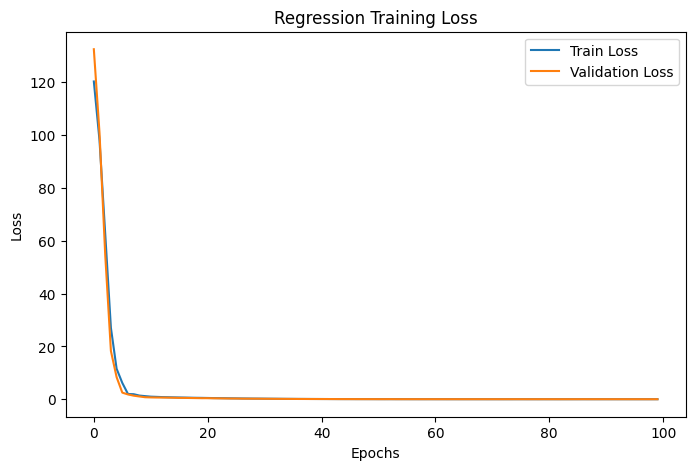

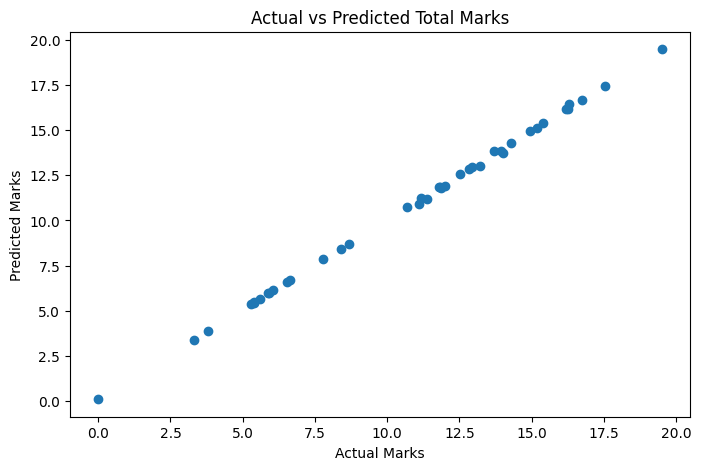

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step

CLASSIFICATION RESULTS
Train Size : 160
Test Size  : 40
Layers     : 3
Neurons    : 16, 8, 1
Activation : ReLU, ReLU, Sigmoid
Loss       : Binary Crossentropy
Learning Rate : 0.01
Epochs     : 100
Accuracy   : 1.0
Precision  : 1.0
Recall     : 1.0
F1 Score   : 1.0


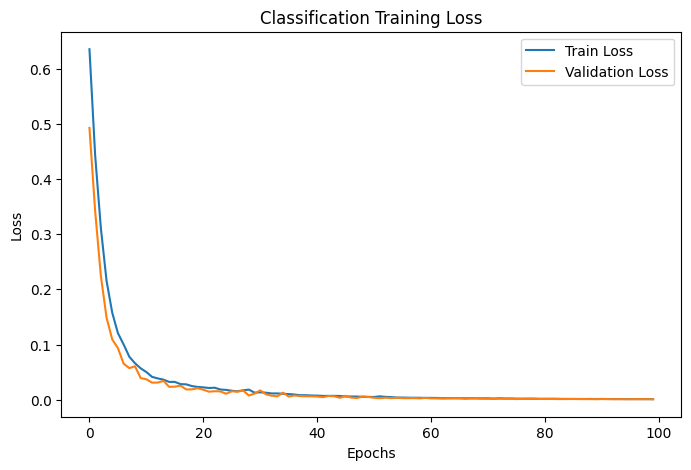

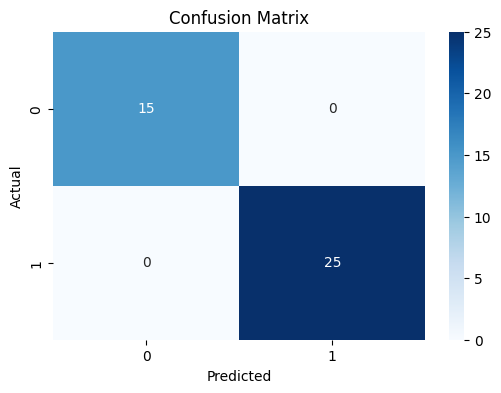

In [ ]:
# -------------------------------
# 1. Import Libraries
# -------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# -------------------------------
# 2. Load Dataset
# -------------------------------
df = pd.read_csv("Student_Marks.csv")

print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

# -------------------------------
# 3. Data Preprocessing
# -------------------------------

# Features
X = df[['EXAM MARKS', 'ASSIGNMENT MARKS', 'ATTENDENCE MARKS']]

# ===============================================
# OBJECTIVE 1 : REGRESSION (Predict TOTAL MARKS)
# ===============================================

y_reg = df['TOTAL MARKS']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------------
# Build FFNN Regression Model
# -------------------------------
reg_model = Sequential([
    Dense(16, activation='relu', input_shape=(3,)),
    Dense(8, activation='relu'),
    Dense(1, activation='linear')
])

reg_model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='mse'
)

history_reg = reg_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

# Predictions
y_pred = reg_model.predict(X_test_scaled)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n==============================")
print("REGRESSION RESULTS")
print("==============================")
print("Train Size :", X_train.shape[0])
print("Test Size  :", X_test.shape[0])
print("Layers     : 3")
print("Neurons    : 16, 8, 1")
print("Activation : ReLU, ReLU, Linear")
print("Loss       : MSE")
print("Learning Rate : 0.01")
print("Epochs     : 100")
print("MSE        :", round(mse,4))
print("R2 Score   :", round(r2,4))

# -------------------------------
# Plot Loss Curve
# -------------------------------
plt.figure(figsize=(8,5))
plt.plot(history_reg.history['loss'], label='Train Loss')
plt.plot(history_reg.history['val_loss'], label='Validation Loss')
plt.title("Regression Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# -------------------------------
# Actual vs Predicted
# -------------------------------
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Total Marks")
plt.show()


# ===============================================
# OBJECTIVE 2 : CLASSIFICATION (Pass / Fail)
# ===============================================

# Encode RESULT column
le = LabelEncoder()
y_clf = le.fit_transform(df['RESULT'])   # P=1 / F=0

# Split
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

# Scale
scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled = scaler2.transform(X_test2)

# -------------------------------
# Build FFNN Classification Model
# -------------------------------
clf_model = Sequential([
    Dense(16, activation='relu', input_shape=(3,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

clf_model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_clf = clf_model.fit(
    X_train2_scaled, y_train2,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

# Prediction
y_prob = clf_model.predict(X_test2_scaled)
y_pred2 = (y_prob > 0.5).astype(int)

# Metrics
acc = accuracy_score(y_test2, y_pred2)
prec = precision_score(y_test2, y_pred2)
rec = recall_score(y_test2, y_pred2)
f1 = f1_score(y_test2, y_pred2)

print("\n==============================")
print("CLASSIFICATION RESULTS")
print("==============================")
print("Train Size :", X_train2.shape[0])
print("Test Size  :", X_test2.shape[0])
print("Layers     : 3")
print("Neurons    : 16, 8, 1")
print("Activation : ReLU, ReLU, Sigmoid")
print("Loss       : Binary Crossentropy")
print("Learning Rate : 0.01")
print("Epochs     : 100")
print("Accuracy   :", round(acc,4))
print("Precision  :", round(prec,4))
print("Recall     :", round(rec,4))
print("F1 Score   :", round(f1,4))

# -------------------------------
# Plot Classification Loss
# -------------------------------
plt.figure(figsize=(8,5))
plt.plot(history_clf.history['loss'], label='Train Loss')
plt.plot(history_clf.history['val_loss'], label='Validation Loss')
plt.title("Classification Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# -------------------------------
# Confusion Matrix
# -------------------------------
cm = confusion_matrix(y_test2, y_pred2)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()